# Week 3: Baseline Predictive Modeling (Churn Prediction)
**Objective:** Transition into predictive analytics using Scikit-Learn to build a baseline classification model (Logistic Regression). The goal is to predict the likelihood of a booking cancellation based on the key features identified during Week 2 EDA.

### Day 1: Importing Libraries

In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

# Cell 2: Load Data
df = pd.read_csv('cleaned_hotel_data_week1.csv')
print(f"Dataset loaded with {df.shape[0]} rows.")


Dataset loaded with 118673 rows.


### Day 2: Feature Selection & Encoding
We select our core features (like `lead_time` and `adr`) and our target variable (`is_canceled`). We then use **One-Hot Encoding** to convert text categories into numbers so the Machine Learning model can read them.


In [3]:
# The Target:  AI is trying to predict
y = df['is_canceled']

# The Features:  make its predictions
features = ['lead_time', 'adr', 'total_of_special_requests', 'market_segment', 'deposit_type', 'customer_type']
X_raw = df[features]

#  convert text categories into numbers
X = pd.get_dummies(X_raw, drop_first=True)

print("Day 2 Complete: Features selected and encoded successfully!")
print(f"Total features after encoding: {X.shape[1]}")

Day 2 Complete: Features selected and encoded successfully!
Total features after encoding: 15


### Day 3: Data Splitting & Scaling
We split our data into 80% for training the AI and 20% for testing it. We also use a **StandardScaler** to balance the numbers so large values (like ADR) don't overpower smaller ones.


In [4]:
# Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Scale the data (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Day 3 Complete: Data successfully split and scaled!")
print(f"Training data size: {X_train.shape[0]} rows.")
 

Day 3 Complete: Data successfully split and scaled!
Training data size: 94938 rows.


### Day 4: Baseline Model Training
We use a **Logistic Regression** model as our baseline. We train the AI on our 80% dataset so it learns exactly how features like `lead_time` influence cancellations.


In [5]:
# Initialize the baseline Logistic Regression model
ml_model = LogisticRegression(max_iter=1000, random_state=42)

# Train (fit) the model using the training data
ml_model.fit(X_train_scaled, y_train)

# Make predictions on the unseen test data
y_pred = ml_model.predict(X_test_scaled)
y_pred_probability = ml_model.predict_proba(X_test_scaled)[:, 1]

print("Day 4 Complete: Logistic Regression model successfully trained!")


Day 4 Complete: Logistic Regression model successfully trained!


### Day 5: Model Evaluation & ROC Curve
We evaluate the model using standard business metrics: **Accuracy, Precision, and Recall**. We also plot an **ROC-AUC Curve** to visually prove its effectiveness to the business team.


Accuracy:  78.33%
Precision: 83.96%
Recall:    51.66%
ROC-AUC:   80.99%


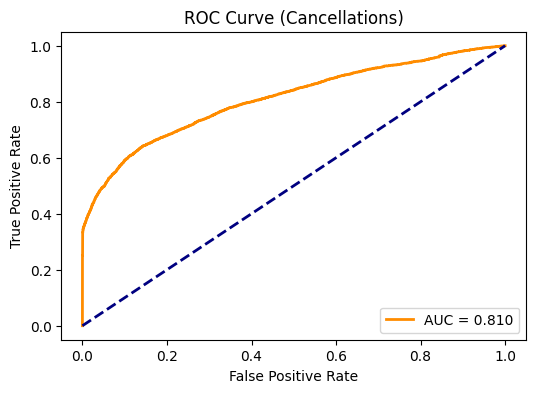

In [6]:
import os

# Calculate all core metrics required by the PDF
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_probability)

# Print them beautifully
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc * 100:.2f}%")

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probability)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Cancellations)')
plt.legend(loc="lower right")

#  save the high-res image
os.makedirs('ML_Models_Images', exist_ok=True)
plt.savefig('ML_Models_Images/roc_curve.png', bbox_inches='tight', dpi=300)

plt.show()


### Day 6: Feature Importance Analysis
We will analyze the mathematical weights (coefficients) the Logistic Regression model assigned to each feature. This tells the business exactly *what* drives a cancellation.


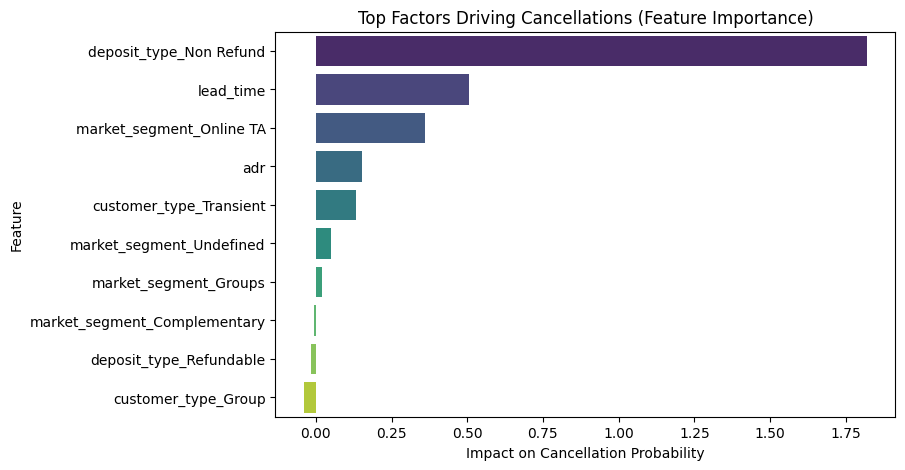

In [7]:
# Extract and display feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': ml_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

# Plot the top features
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top Factors Driving Cancellations (Feature Importance)')
plt.xlabel('Impact on Cancellation Probability')

# save images
import os
os.makedirs('ML_Models_Images', exist_ok=True)
plt.savefig('ML_Models_Images/feature_importance.png', bbox_inches='tight', dpi=300)

plt.show()
